# Bayesian analysis in `easyscience`

When doing Bayesian model-based analysis, the goal is to find the most probable model, given the measured data, as this would be our best guess of the model of the measured system.<br>
To calculate how probable a model $H$ (or hypothesis, in Bayesian terms) is, given the data $E$ (called the evidence, in Bayesian terms), we use Bayes' theorem:
$$
P(H|E) = \frac{P(E|H)P(H)}{P(E)} \propto P(E|H)P(H),
$$ (bayes)
where $P(H|E)$ is the probability of the model given the data (called the posterior distribution in Bayesian terms), $P(E|H)$ is the probability of the data given the model, this is equiavalent to the likehood we've worked with thus far, $P(H)$ is our best guess at how probable it is that a given model is the correct one (called the prior in Bayesian terms), and $P(E)$ is called the evidence term. The evidence term is often ignored when finding the most probable model, as it only depends on the data $E$ (evidence) and thus doesn't change when trying out different models.

Finding the model which maximizes {eq}`bayes` can be quite difficult, as it involves computing a potentially high-dimensional integral (1 dimension per model parameter).<br>
As is often the case in such situations, we therefore resort to statistical sampling methods, such as Monte Carlo methods, like the one you used to simulate your neutron data, to evaluate the integral.<br>
Specifically, a popular tool to evaluate {eq}`bayes` is the [Markov chain](https://en.wikipedia.org/wiki/Markov_chain) Monte Carlo (MCMC) algorithm. This algorithm is available in `easyscience`. How it works is outside the scope of this summer school.

## 🛠️ Import Library
As always, we start by importing the `easyscience` library and other supporting libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from easyscience import global_object

We disable the legacy warning again.

In [2]:
global_object.log.getLogger('legacy').setLevel('ERROR') # suppress warnings from legacy code in this notebook

And import `easyscience`

In [3]:
import easyscience as es

## 📘 Introduction: Bayesian analysis
`easyscience` interfaces with the backend `DREAM` (DiffeRential Evolution Adaptive Metropolis) of `BUMPS` which enables MCMC sampling. 

MCMC sampling is more computationally expensive than conventional fitting, therefore it is often a good idea to have a good estimate for the parameters which maximizes the likelihood, to be used as a starting point for the Bayesian analysis.<br>
Hence we start with a normal Maximum Likelihood Estimation (MLE) fit like what we've done so far.

We use the same quadratic data as in the first notebook today.

In [4]:
np.random.seed(123)

a_true = -0.9594
b_true = 7.294
c_true = 3.102

N = 25
x = np.linspace(0, 10, N)
yerr = 1 + 1 * np.random.rand(N)
y = a_true * x ** 2 + b_true * x + c_true
y += np.abs(y) * 0.1 * np.random.randn(N)

We then create our `easyscience` parameters and do the fit. Here it is **important** that we define bounds for the parameters, as these bounds will be used as uniform probability distrubtions for the priors $P(H)$ of {eq}`bayes`.

In [5]:
a = es.Parameter(name='a', value=a_true, fixed=False, min=-5.0, max=0.5)
b = es.Parameter(name='b', value=b_true, fixed=False, min=0, max=10)
c = es.Parameter(name='c', value=c_true, fixed=False, min=-20, max=50)

def math_model(x: np.ndarray) -> np.ndarray:
    """
    Mathematical model for a quadratic. 
    
    :x: values to calculate the model over. 
    
    :return: model values.
    """
    return a.value * x ** 2 + b.value * x + c.value

container = es.ObjBase(name='quad', a=a, b=b, c=c)
fitter = es.Fitter(container, math_model)

results = fitter.fit(x=x, y=y, weights=1/yerr)

a, b, c

(<Parameter 'a': -0.9455 ± 0.0379, bounds=[-5.0:0.5]>,
 <Parameter 'b': 7.3277 ± 0.3800, bounds=[0.0:10.0]>,
 <Parameter 'c': 2.0301 ± 0.8187, bounds=[-20.0:50.0]>)

To perform the MCMC sampling, we must then switch the fitters minimizer to BUMPS, since DREAM is only available in BUMPS.

In [6]:
fitter.switch_minimizer(es.AvailableMinimizers.Bumps)

We can then create our MCMC sampler by giving it the observed data as well as the fitter.

In [7]:
sampler = es.fitting.Sampler(
    fitter=fitter,
    x=x,
    y=y,
    weights=1/yerr
)

We are now ready to start the MCMC sampling. The MCMC sampling starts from the initial parameter values and takes a while to reach convergence, hence we remove (burn) the first 500 samples. <br>
We also remove (thin) every 2nd sample to avoid autocorrelation between subsequent samples.

In [8]:
results = sampler.sample(samples=10000, burn=500, thin=2)

We then need to check if our MCMC sampling converged. To do this we plot the MCMC chains and check that sampling is carried out evenly, i.e. that the chains look like pure noise / "hairy caterpillars".

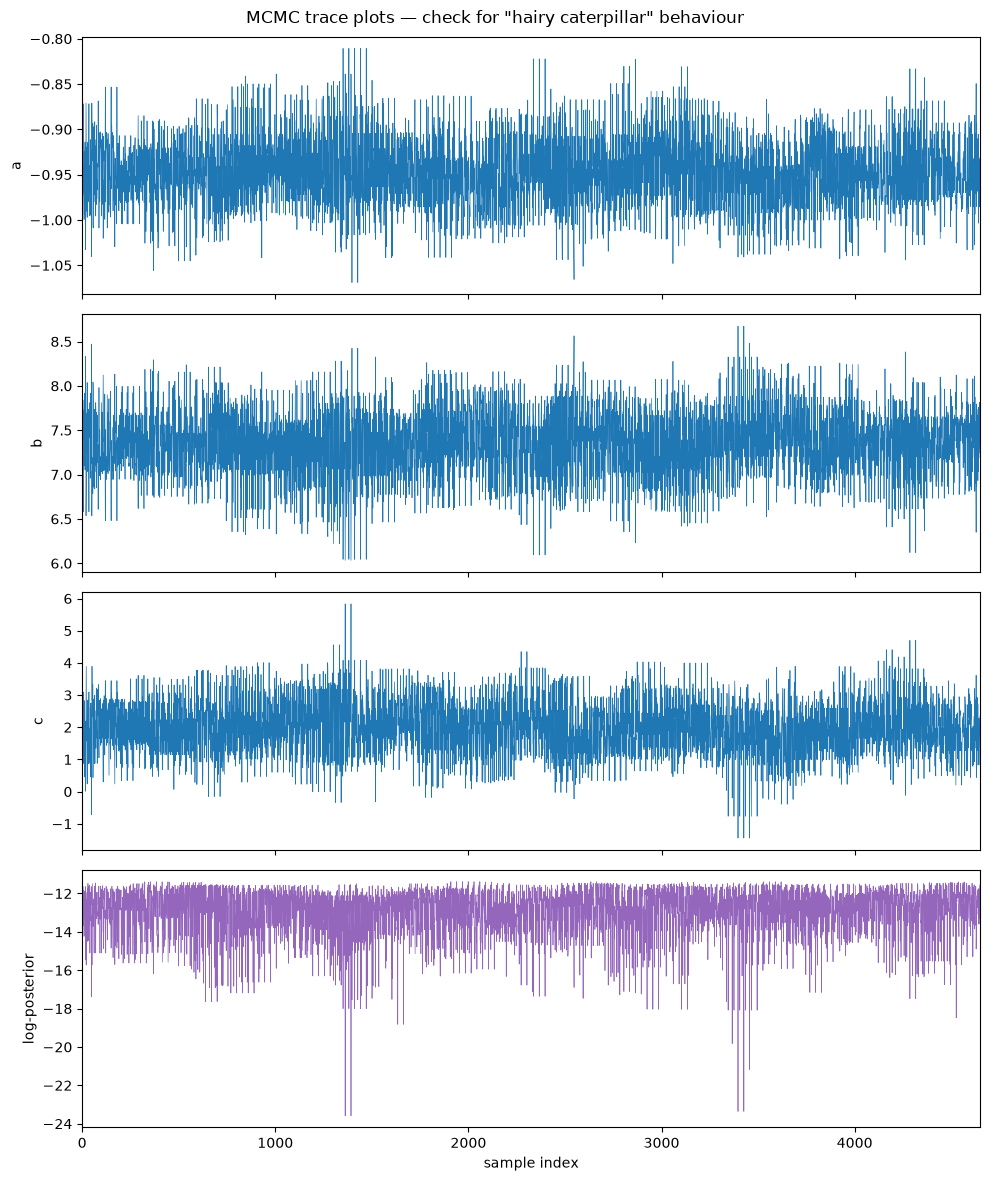

In [9]:
draws = results.draws
logp = results.logp
name_to_col = {name: idx for idx, name in enumerate(results.param_names)}


def column_for(parameter):
    return draws[:, name_to_col[parameter.unique_name]]


fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

# Trace plots for each parameter
for ax, (label, par) in zip(
    axes[:3],
    (('a', a), ('b', b), ('c', c)),
):
    ax.plot(column_for(par), lw=0.5)
    ax.set_ylabel(label)
    ax.set_xlim(0, len(draws) - 1)

# Log-posterior trace
axes[3].plot(logp, lw=0.5, color='C4')
axes[3].set_ylabel('log-posterior')
axes[3].set_xlabel('sample index')

fig.suptitle('MCMC trace plots — check for "hairy caterpillar" behaviour')
fig.tight_layout()
plt.show()

We see that our MCMC sampling is sufficiently converged and we therefore investigate the results. We start by compariong the model parameters of our most probable Bayesian model, with the parameters we got with normal fitting.

In [10]:
summary_rows = []
for label, par in (
    ('a', a),
    ('b', b),
    ('c', c),
):
    col = column_for(par)
    lo, med, hi = np.percentile(col, [16, 50, 84])
    summary_rows.append((label, med, med - lo, hi - med, par.value))

print(f'{"param":<8s} {"median":>12s} {"16th":>12s} {"84th":>12s} {"MLE":>12s}')
for label, med, low, high, mle in summary_rows:
    print(f'{label:<8s} {med:12.4g} {low:12.4g} {high:12.4g} {mle:12.4g}')

param          median         16th         84th          MLE
a             -0.9474      0.03647      0.03822       -1.037
b               7.341       0.3642       0.3746        8.081
c               1.995       0.8342       0.8517        1.123


We notice that the results are slightly better, the paremeter $b$ is closer to its real value of 7.294. <br>
A more important distinction is the uncertainties on the parameters. In the normal fitting routine, the uncertainties reflect standard deviations on a normal distribution, because we assume the validity of the Central Limit Theorem.<br>
In Bayesian analysis we directly get the probability distribution of the model parameters, and this can be a skewed distribution, as we can see from the 16th and 84th percentiles of the Bayesian analysis.<br>

Another advantage of Bayesian analysis is that we can also get a measure of the correlation between the parameters.

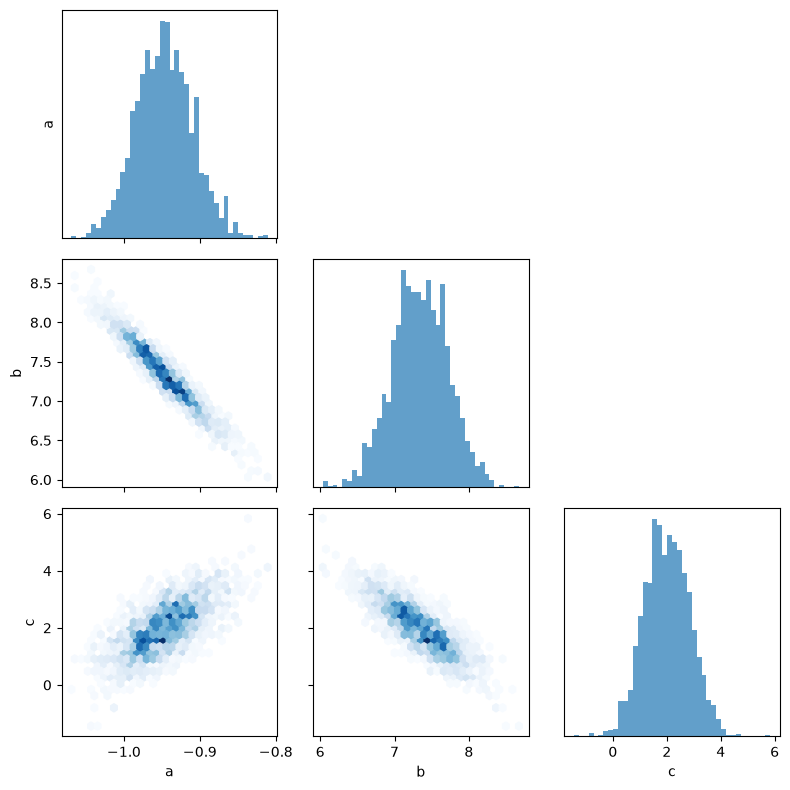

In [11]:
labels = ['a', 'b', 'c']
cols = np.column_stack([column_for(p) for p in (a, b, c)])
n = len(labels)

fig, axes = plt.subplots(n, n, figsize=(8, 8))
for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        if j > i:
            ax.set_visible(False)
            continue
        if i == j:
            ax.hist(cols[:, i], bins=40, color='C0', histtype='stepfilled', alpha=0.7)
            ax.set_yticks([])
        else:
            ax.hexbin(cols[:, j], cols[:, i], gridsize=30, cmap='Blues', mincnt=1)
        if i == n - 1:
            ax.set_xlabel(labels[j])
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
fig.tight_layout()
plt.show()

We've here plotted the the probability distributions for the model parameters, as well as their correlations. For example we can here ee that `a` is negatively correlated with `b` but positively correlated with `c´.

Finally we can also plot our credible interval of our model, which gives us the band within which we can be 95% sure that the real model parameters lie.

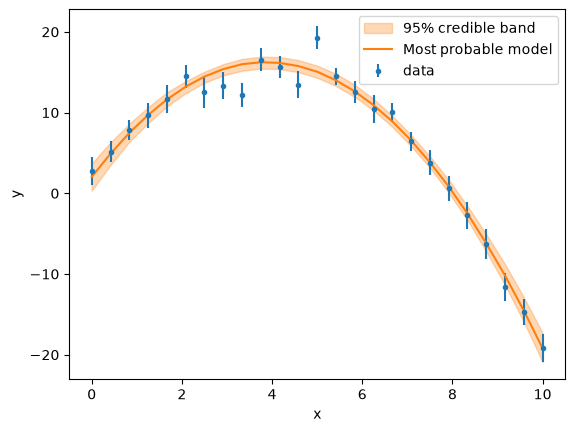

In [12]:
rng = np.random.default_rng(seed=0)
n_draws = 300
indices = rng.choice(draws.shape[0], size=n_draws, replace=False)

predictions = np.empty((n_draws, x.size))
saved = {p.unique_name: p.value for p in (a, b, c)}
try:
    for k, idx in enumerate(indices):
        a.value = draws[idx, name_to_col[a.unique_name]]
        b.value = draws[idx, name_to_col[b.unique_name]]
        c.value = draws[idx, name_to_col[c.unique_name]]
        predictions[k] = math_model(x)
finally:
    for p in (a, b, c):
        p.value = saved[p.unique_name]

lo = np.percentile(predictions, 2.5, axis=0)
hi = np.percentile(predictions, 97.5, axis=0)
mid = np.percentile(predictions, 50, axis=0)

fig, ax = plt.subplots()
ax.errorbar(x, y, yerr, fmt='.', label='data')
ax.fill_between(x, lo, hi, color='C1', alpha=0.3, label='95% credible band')
ax.plot(x, mid, '-', color='C1', label='Most probable model')
ax.set(xlabel='x', ylabel='y')
ax.legend()
plt.show()